### Snow Model Forcing
#### `4_compare_wind_fields.ipynb` 
#### Now, load all other wind fields and compare point simulations of wind speed

Notebook contents 
* this is working directly off of `3_read_wind_ninja_output_ascii.ipynb` to take a look at the output created there 

created by Cassie Lumbrazo\
last updated: Oct 2025\
run location: UAS linux\
python environment: **rasterio**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

In [14]:
import geopandas as gpd
from shapely.geometry import Point

# Open Wind Ninja Output
created in `3_read_wind_ninja_output_ascii` notebook

In [21]:
# open the output netcdf 
ds_wn = xr.open_dataset("/hdd/snow_hydrology/wind_ninja/test5/output/windninja_timeseries.nc")
# ds_wn.rio.write_crs('EPSG:4326', inplace=True)  # the data is in lat/lon, that's not true.. it is not in lat/lon, it is in UTM Zone 8N, so we need to set the CRS to EPSG:32608
ds_wn.rio.write_crs('EPSG:32608', inplace=True)
ds_wn

<xarray.Dataset> Size: 39MB
Dimensions:      (time: 721, y: 78, x: 87)
Coordinates:
  * time         (time) datetime64[ns] 6kB 2024-11-01 ... 2024-12-01
  * x            (x) float64 696B 5.238e+05 5.239e+05 ... 5.323e+05 5.324e+05
  * y            (y) float64 624B 6.463e+06 6.463e+06 ... 6.456e+06 6.455e+06
    spatial_ref  int64 8B 0
Data variables:
    wind_speed   (time, y, x) float32 20MB ...
    wind_dir     (time, y, x) float32 20MB ...

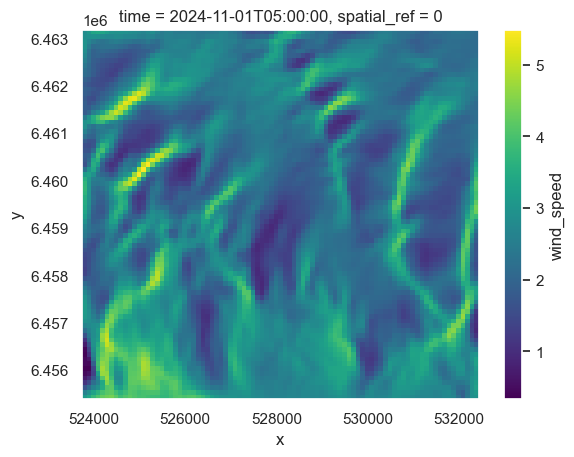

In [26]:
# plot a single timestep 
ds_wn.isel(time=5).wind_speed.plot()

The coordinate values (~5.2e5, 6.4e6)... so likely in meters

In [22]:
print(ds_wn.rio.crs)

EPSG:32608


### So, we are in UTM Zone 8N (EPSG:32608)

So I need to project the latitude/longitude coordinates (currently in WGS84) into EPSG:32608, then plot them

In [ ]:
# Site coordinates (lat/lon, WGS84)
lat_faa, lon_faa = 58.26139, -134.51056
lat_powderpatch, lon_powderpatch = 58.26200, -134.51700

# Create GeoDataFrame for the two sites
gdf_sites = gpd.GeoDataFrame({
    "site": ["FAA", "Powder Patch"],
    "geometry": [Point(lon_faa, lat_faa), Point(lon_powderpatch, lat_powderpatch)]
}, crs="EPSG:4326")

# Convert sites to same projection as dataset (UTM Zone 8N)
gdf_sites_proj = gdf_sites.to_crs("EPSG:32608")

# Extract projected coordinates
x_faa, y_faa = gdf_sites_proj.geometry[0].x, gdf_sites_proj.geometry[0].y
x_pp, y_pp = gdf_sites_proj.geometry[1].x, gdf_sites_proj.geometry[1].y

And plot them to visualize the gridcells, 

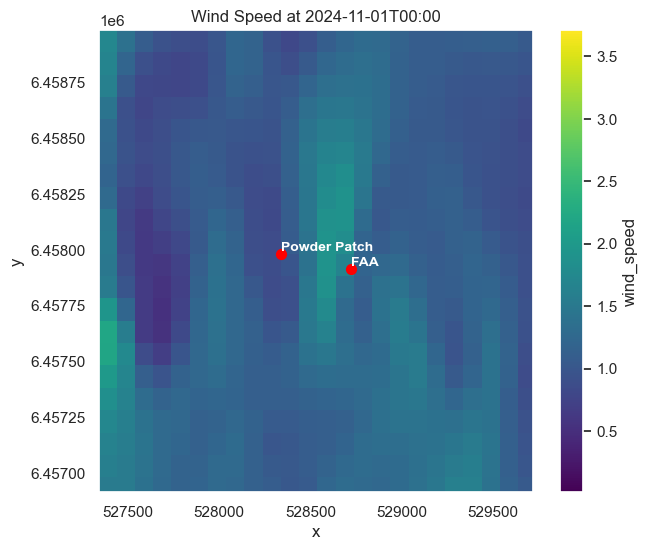

In [32]:
# Choose one time step (e.g., first one)
t0 = ds_wn.time[0]

# Select wind speed variable for that time
da_plot = ds_wn["wind_speed"].sel(time=t0)

# Plot
fig, ax = plt.subplots(figsize=(7, 6))
da_plot.plot(ax=ax, cmap="viridis")

# Overlay points
ax.scatter([x_faa, x_pp], [y_faa, y_pp], color="red", s=50, zorder=3)
ax.text(x_faa, y_faa, "FAA", color="white", fontsize=10, weight="bold", ha="left", va="bottom")
ax.text(x_pp, y_pp, "Powder Patch", color="white", fontsize=10, weight="bold", ha="left", va="bottom")

# Zoom in around the two sites
# buffer = 100  # meters (adjust for resolution)
buffer = 1000  # woul dbe 1km on each side
ax.set_xlim(min(x_faa, x_pp) - buffer, max(x_faa, x_pp) + buffer)
ax.set_ylim(min(y_faa, y_pp) - buffer, max(y_faa, y_pp) + buffer)

ax.set_title(f"Wind Speed at {str(t0.values)[:16]}")
plt.show()

### Make an animation and save (need to move to a new script later....)

In [33]:
from matplotlib.animation import FuncAnimation, PillowWriter

In [45]:
# da = ds_wn['wind_speed']

# if I want only one day or a shorter time period 
da = ds_wn['wind_speed'].sel(time=slice('2024-11-01', '2024-11-02'))

fig, ax = plt.subplots(figsize=(7, 6))

# Overlay points
ax.scatter([x_faa, x_pp], [y_faa, y_pp], color="red", s=50, zorder=3)
ax.text(x_faa, y_faa, "FAA", color="white", fontsize=10, weight="bold", ha="left", va="bottom")
ax.text(x_pp, y_pp, "Powder Patch", color="white", fontsize=10, weight="bold", ha="left", va="bottom")

# Zoom in around the two sites
buffer = 100  # in meters, 1000 would be 1km on each side

img = da.isel(time=0).plot(ax=ax, cmap="viridis")
ax.set_title(str(da.time.values[0])[:16])

def update(i):
    img.set_array(da.isel(time=i).values.ravel())
    # FIX: no extra .values here
    ax.set_title(str(da.time.values[i])[:16])
    ax.set_xlim(min(x_faa, x_pp) - buffer, max(x_faa, x_pp) + buffer)
    ax.set_ylim(min(y_faa, y_pp) - buffer, max(y_faa, y_pp) + buffer)
    return [img]

ani = FuncAnimation(fig, update, frames=len(da.time), interval=200, blit=True)

# save as gif
ani.save('/home/cassie/data/windninja/gif/wn_wind_speed_1_2_Nov_with_points_100m.gif', writer=PillowWriter(fps=5))
plt.close()

### Select the gridcells "nearest" to the points

In [35]:
# ds_wn_faa = ds_wn.sel(y=lat_faa, x=lon_faa, method='nearest') # this works, but we need to be careful that the lat/lon are in UTM (meters)

# Site lat/lon
lat_faa, lon_faa = 58.26139, -134.51056
lat_powderpatch, lon_powderpatch = 58.26200, -134.51700

# Convert to UTM Zone 8N
gdf_sites = gpd.GeoDataFrame({
    "site": ["FAA", "Powder Patch"],
    "geometry": [Point(lon_faa, lat_faa), Point(lon_powderpatch, lat_powderpatch)]
}, crs="EPSG:4326").to_crs("EPSG:32608")

x_faa, y_faa = gdf_sites.geometry[0].x, gdf_sites.geometry[0].y
x_pp, y_pp = gdf_sites.geometry[1].x, gdf_sites.geometry[1].y

# Select nearest grid cells
ds_wn_faa = ds_wn.sel(x=x_faa, y=y_faa, method="nearest")
ds_wn_powderpatch = ds_wn.sel(x=x_pp, y=y_pp, method="nearest")

print(ds_wn_faa)
print(ds_wn_powderpatch)

<xarray.Dataset> Size: 12kB
Dimensions:      (time: 721)
Coordinates:
  * time         (time) datetime64[ns] 6kB 2024-11-01 ... 2024-12-01
    x            float64 8B 5.287e+05
    y            float64 8B 6.458e+06
    spatial_ref  int64 8B 0
Data variables:
    wind_speed   (time) float32 3kB ...
    wind_dir     (time) float32 3kB ...
<xarray.Dataset> Size: 12kB
Dimensions:      (time: 721)
Coordinates:
  * time         (time) datetime64[ns] 6kB 2024-11-01 ... 2024-12-01
    x            float64 8B 5.284e+05
    y            float64 8B 6.458e+06
    spatial_ref  int64 8B 0
Data variables:
    wind_speed   (time) float32 3kB ...
    wind_dir     (time) float32 3kB ...


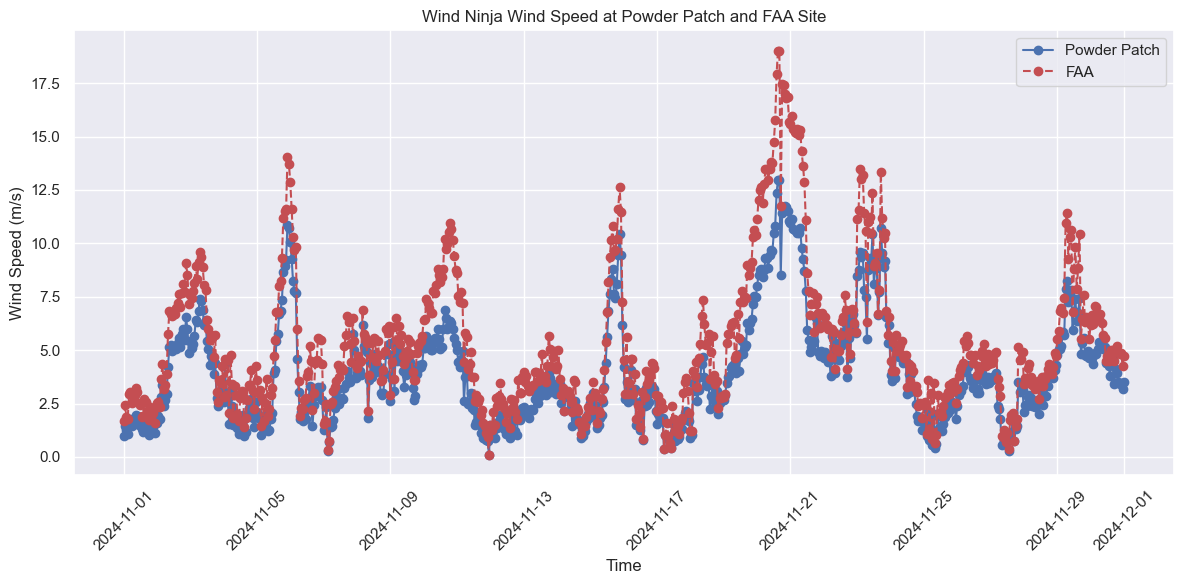

In [37]:
# zoom in the xaxis to see the time series better
plt.figure(figsize=(12, 6))
plt.plot(ds_wn_powderpatch['time'].values, ds_wn_powderpatch['wind_speed'].values, marker='o', linestyle='-', color='b')
plt.plot(ds_wn_faa['time'].values, ds_wn_faa['wind_speed'].values, marker='o', linestyle='--', color='r')
plt.title('Wind Ninja Wind Speed at Powder Patch and FAA Site')
plt.xlabel('Time')
plt.ylabel('Wind Speed (m/s)')
plt.legend(['Powder Patch', 'FAA'])
plt.xticks(rotation=45)
# plt.grid(True)
plt.tight_layout()
plt.show()

Now, this looks better. We should have differences in the two timeseries datasets now, 

In [46]:
# check if there is a difference between the two time series by calculating the mean and standard deviation of the differences
wind_speed_diff = ds_wn_powderpatch['wind_speed'].values - ds_wn_faa['wind_speed'].values
mean_diff = np.mean(wind_speed_diff)
std_diff = np.std(wind_speed_diff)
print(f'Mean difference in wind speed: {mean_diff:.2f} m/s')
print(f'Standard deviation of difference in wind speed: {std_diff:.2f} m/s')

Mean difference in wind speed: -1.33 m/s
Standard deviation of difference in wind speed: 1.09 m/s


# Open the HRRR Input Data 
and then we will bring the wind speed from the tower at Powder Patch and compare them all. 

In [51]:
# read this input file 
hrrr_input_file = "/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_f567_WY2025_test1_utm_1monthonly.nc"

ds_hrrr = xr.open_dataset(hrrr_input_file)
ds_hrrr.rio.write_crs('EPSG:32608', inplace=True)  # the data is in UTM zone 8N
ds_hrrr

<xarray.Dataset> Size: 5MB
Dimensions:                  (time: 721, y: 20, x: 21)
Coordinates:
    step                     (time) timedelta64[ns] 6kB ...
  * time                     (time) datetime64[ns] 6kB 2024-11-01 ... 2024-12-01
    valid_time               (time) datetime64[ns] 6kB ...
  * x                        (x) float64 168B 5.039e+05 5.069e+05 ... 5.633e+05
  * y                        (y) float64 160B 6.495e+06 6.492e+06 ... 6.439e+06
    boundaryLayerCloudLayer  float64 8B ...
    spatial_ref              int64 8B 0
Data variables:
    u10                      (time, y, x) float32 1MB ...
    v10                      (time, y, x) float32 1MB ...
    wind_speed               (time, y, x) float32 1MB ...
    wind_direction           (time, y, x) float32 1MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP

In [52]:
# check the crs 
print(ds_hrrr.rio.crs)

EPSG:32608


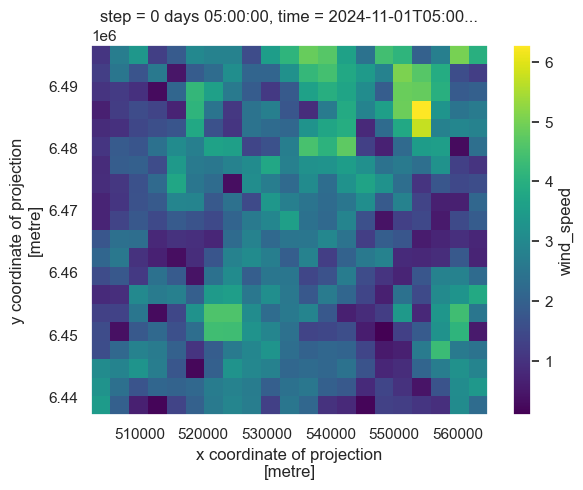

In [53]:
# plot a single timestep 
ds_hrrr.isel(time=5).wind_speed.plot()

Select the Powder Patch Gridcell

In [54]:
# Select nearest grid cells
ds_hrrr_faa = ds_hrrr.sel(x=x_faa, y=y_faa, method="nearest")
ds_hrrr_powderpatch = ds_hrrr.sel(x=x_pp, y=y_pp, method="nearest")

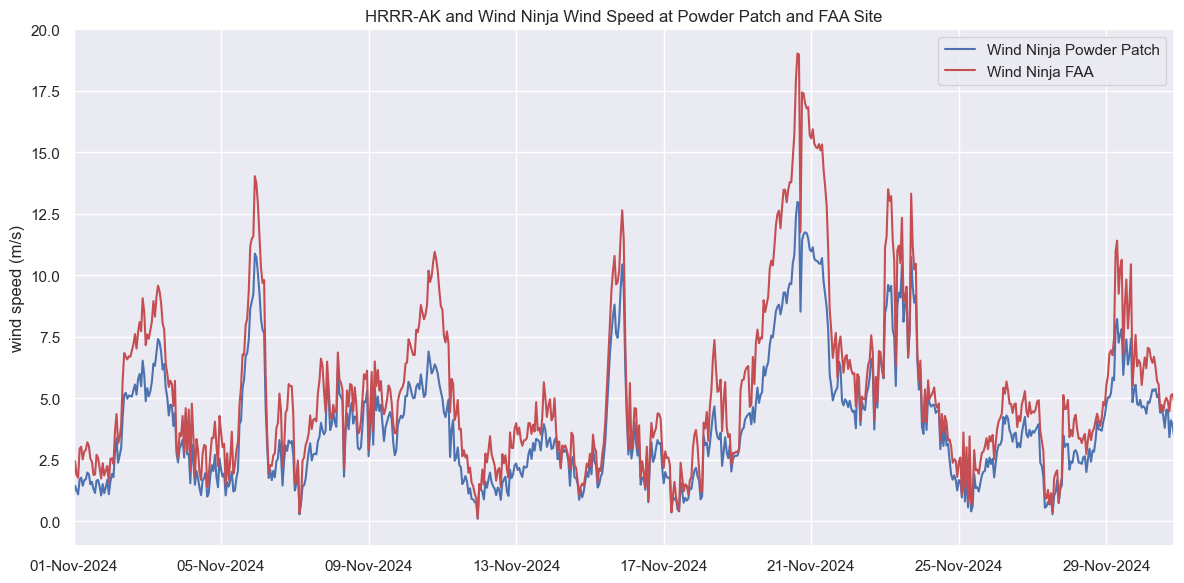

In [165]:
# zoom in the xaxis to see the time series better
plt.figure(figsize=(12, 6))
# plt.plot(ds_hrrr_powderpatch['time'].values, ds_hrrr_powderpatch['wind_speed'].values, color='lightblue', label='HRRR-AK Powder Patch')
plt.plot(ds_wn_powderpatch['time'].values, ds_wn_powderpatch['wind_speed'].values, color='b', label='Wind Ninja Powder Patch')

# plt.plot(ds_hrrr_faa['time'].values, ds_hrrr_faa['wind_speed'].values, color='lightcoral', label='HRRR-AK FAA')
plt.plot(ds_wn_faa['time'].values, ds_wn_faa['wind_speed'].values, color='r', label='Wind Ninja FAA')

plt.title('HRRR-AK and Wind Ninja Wind Speed at Powder Patch and FAA Site')
plt.xlabel('')
plt.ylabel('wind speed (m/s)')
plt.legend()
# plt.xticks(rotation=45)
# set the date format on the x-axis to be more readable
plt.gca().xaxis.set_major_formatter(mpl.dates.DateFormatter('%d-%b-%Y'))

# set y and x lim to stay the same 
plt.ylim(-1, 20)
plt.xlim(ds_wn_powderpatch['time'].values[0], ds_wn_powderpatch['time'].values[-5])

# plt.grid(True)
plt.tight_layout()
plt.show()

### Animation again, 

In [164]:
from matplotlib.animation import FuncAnimation, PillowWriter

# --- Select matching time subset ---
da_wn   = ds_wn['wind_speed'].sel(time=slice('2024-11-01', '2024-11-02'))
da_hrrr = ds_hrrr['wind_speed'].sel(time=slice('2024-11-01', '2024-11-02'))

# --- Create side-by-side subplots ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

# --- Initial plots ---
img1 = da_hrrr.isel(time=0).plot(ax=ax1, cmap='viridis', add_colorbar=False)
img2 = da_wn.isel(time=0).plot(ax=ax2, cmap='viridis', add_colorbar=True)
ax1.set_title('HRRR Wind Speed')
ax2.set_title('WindNinja Wind Speed')

# --- Overlay sites ---
for ax in (ax1, ax2):
    ax.scatter([x_faa, x_pp], [y_faa, y_pp], color='red', s=50, zorder=3)
    ax.text(x_faa, y_faa, 'FAA', color='white', fontsize=10, weight='bold',
            ha='left', va='bottom')
    ax.text(x_pp, y_pp, 'Powder Patch', color='white', fontsize=10, weight='bold',
            ha='left', va='bottom')

# --- Zoom extent ---
# buffer = 1000  # meters
# ax1.set_xlim(min(x_faa, x_pp) - buffer, max(x_faa, x_pp) + buffer)
# ax1.set_ylim(min(y_faa, y_pp) - buffer, max(y_faa, y_pp) + buffer)

# --- Update function ---
def update(i):
    # Update arrays
    img1.set_array(da_hrrr.isel(time=i).values.ravel())
    img2.set_array(da_wn.isel(time=i).values.ravel())

    # Shared timestamp
    timestamp = str(da_wn.time.values[i])[:16]
    fig.suptitle(f'Wind Speed – {timestamp}', fontsize=14)

    return [img1, img2]

# --- Animate ---
frames = min(len(da_wn.time), len(da_hrrr.time))
ani = FuncAnimation(fig, update, frames=frames, interval=200, blit=True)

# --- Save as GIF ---
ani.save('/home/cassie/data/windninja/gif/hrrr_vs_wn_wind_speed_nozoom.gif',
         writer=PillowWriter(fps=5))

plt.close()

# Open the met station datasets from WY2025
we only need the month of Novemeber for now...

In [131]:
# These are the met station data from WY2025
filename = '/home/cassie/data/fishcreek/mesonet/rawdata/DouglasIsland_AllStations_RawData_WY2025_until16March2025.txt'

# open
df_met = pd.read_csv(filename, sep = ",")

# make utc_valid a datetime and index the df_met by it 
df_met['datetime'] = pd.to_datetime(df_met['utc_valid'])
df_met = df_met.set_index('datetime')
# df_met.head()
# list the unique variables in the 'station' column

# cut the entire df_met to the month of november 
df_met = df_met.sort_index()
df_met = df_met.loc['2024-11-01':'2024-11-30']

df_met['station'].unique()

array(['ECEA2', 'JECA2', 'PPSA2', 'NDIA2', 'SDIA2', 'ECTA2'], dtype=object)

In [132]:
# the two most likely sites
df_met_ECEA2 = df_met.where(df_met['station'] == 'ECEA2')
df_met_ECTA2 = df_met.where(df_met['station'] == 'ECTA2')
df_met_JECA2 = df_met.where(df_met['station'] == 'JECA2')

# drop the row if the entire row is nan 
df_met_ECEA2 = df_met_ECEA2.dropna(how='all')
df_met_ECTA2 = df_met_ECTA2.dropna(how='all')
df_met_JECA2 = df_met_JECA2.dropna(how='all')

# drop the column if the entire column is nan 
df_met_ECEA2 = df_met_ECEA2.dropna(axis=1, how='all')
df_met_ECTA2 = df_met_ECTA2.dropna(axis=1, how='all')
df_met_JECA2 = df_met_JECA2.dropna(axis=1, how='all')

# df_met_ECEA2_wind = df_met_ECEA2.filter(regex='^U') # keep only the variables which start with a U 

df_met_ECEA2.head()

,station,utc_valid,PPIRZZZ,TAIRZZZ,XRIRZZZ
datetime,,,,,
2024-11-01 00:00:00,ECEA2,2024-11-01 00:00:00,NaN,36.0,NaN
2024-11-01 00:05:00,ECEA2,2024-11-01 00:05:00,NaN,36.0,NaN
2024-11-01 00:11:00,ECEA2,2024-11-01 00:11:00,NaN,36.0,NaN
2024-11-01 00:16:00,ECEA2,2024-11-01 00:16:00,NaN,36.0,NaN
2024-11-01 00:21:00,ECEA2,2024-11-01 00:21:00,NaN,37.0,NaN


In [133]:
df_met_JECA2_wind = df_met_JECA2.filter(regex='^U') # keep only the variables which start with a U 
df_met_JECA2_wind.head()

,UDIRZZZ,UPIRZZZ,USIRZZZ
datetime,,,
2024-11-01 00:00:00,137.0,12.0,11.0
2024-11-01 00:01:00,126.0,14.0,13.0
2024-11-01 00:02:00,131.0,14.0,12.0
2024-11-01 00:03:00,136.0,12.0,11.0
2024-11-01 00:04:00,137.0,12.0,10.0


In [ ]:
df_met_ECTA2

,station,utc_valid,PPDRZZZ,PPVRZZZ,PTIRZZZ,SDIRZZZ,SFDRZZZ,SFVRZZZ,TAIRZNZ,TAIRZXZ,TAIRZZZ,UDIRZZZ,UGIRZZZ,UPIRZZZ,URIRZZZ,USIRZZZ,VVIRZZZ,XCIRZZZ,XPQRZZZ,XWIRZZZ
datetime,,,,,,,,,,,,,,,,,,,,
2024-11-09 17:00:00,ECTA2,2024-11-09 17:00:00,NaN,0.47,NaN,25.0,NaN,3.2,30.0,31.0,31.0,113.0,21.0,42.0,135.0,19.0,90.0,8.0,2.0,3.0
2024-11-22 18:00:00,ECTA2,2024-11-22 18:00:00,0.0,NaN,NaN,33.0,0.0,NaN,13.0,19.0,19.0,44.0,29.0,54.0,22.0,25.0,99.0,0.0,0.0,1.0
2024-11-23 18:30:00,ECTA2,2024-11-23 18:30:00,0.0,NaN,NaN,33.0,0.0,NaN,13.0,19.0,13.0,45.0,20.0,51.0,0.0,14.0,99.0,0.0,0.0,1.0
2024-11-24 18:00:00,ECTA2,2024-11-24 18:00:00,0.0,NaN,NaN,NaN,0.0,NaN,13.0,18.0,18.0,23.0,13.0,45.0,23.0,13.0,99.0,0.0,0.0,1.0
2024-11-27 20:00:00,ECTA2,2024-11-27 20:00:00,NaN,0.84,5.0,42.0,NaN,9.4,25.0,27.0,25.0,45.0,14.0,31.0,112.0,4.0,NaN,8.0,7.0,71.0


<Axes: xlabel='datetime'>

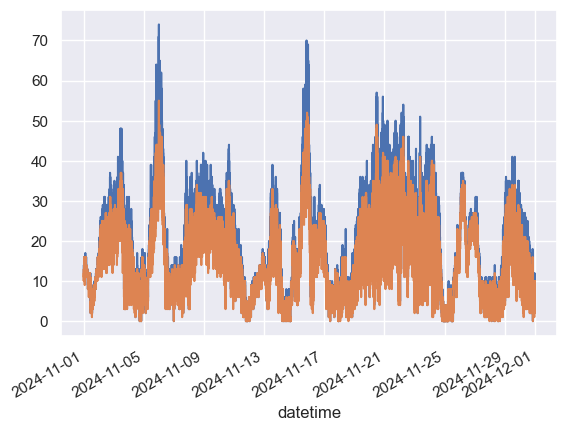

In [134]:
df_met_JECA2_wind['UPIRZZZ'].plot()
df_met_JECA2_wind['USIRZZZ'].plot()

In [135]:
# convert miles per hour to meters per second 
# df_met_JECA2_wind_cut['WSPD_mps'] = df_met_JECA2_wind_cut['USIRZZZ'] * 0.44704

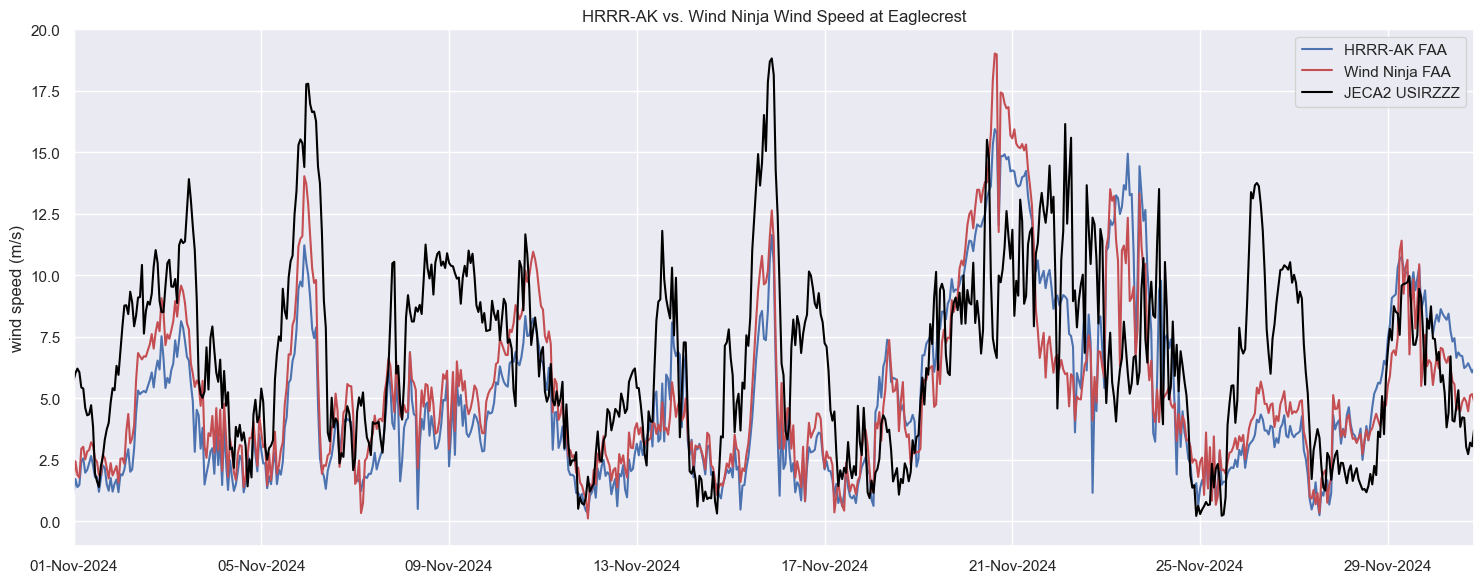

In [163]:
# and plot the timeseries 
plt.figure(figsize=(15, 6))

plt.plot(ds_hrrr_faa['time'].values, ds_hrrr_faa['wind_speed'].values, color='b', label='HRRR-AK FAA')
plt.plot(ds_wn_faa['time'].values, ds_wn_faa['wind_speed'].values, color='r', label='Wind Ninja FAA')

# plt.plot((df_met_JECA2_wind['UPIRZZZ']* 0.44704).resample('h').mean(), color='darkgreen', label='JECA2 UPIRZZZ')
plt.plot((df_met_JECA2_wind['USIRZZZ']* 0.44704).resample('h').mean(), color='black', label='JECA2 USIRZZZ')
# plt.plot((df_met_JECA2_wind['USIRZZZ']* 0.44704), color='black', label='JECA2 USIRZZZ')

# plt.plot((df_met_ECTA2_wind['USIRZZZ']* 0.44704).resample('h').mean(), color='orange', label='ECTA2 USIRZZZ')
# plt.plot((df_met_ECTA2_wind['URIRZZZ']* 0.44704).resample('h').mean(), color='red', label='ECTA2 URIRZZZ')
# plt.plot((df_met_ECTA2_wind['UPIRZZZ']* 0.44704).resample('h').mean(), color='purple', label='ECTA2 UPIRZZZ')

# plt.plot(df_met_ECTA2_wind['USIRZZZ'], color='orange', label='ECTA2 USIRZZZ')
# plt.plot(df_met_ECTA2_wind['URIRZZZ'], color='red', label='ECTA2 URIRZZZ')
# plt.plot(df_met_ECTA2_wind['UPIRZZZ'], color='purple', label='ECTA2 UPIRZZZ')

plt.title('HRRR-AK vs. Wind Ninja Wind Speed at Eaglecrest')

plt.xlabel('')
plt.ylabel('wind speed (m/s)')
plt.legend()
# plt.xticks(rotation=45)
# set the date format on the x-axis to be more readable
plt.gca().xaxis.set_major_formatter(mpl.dates.DateFormatter('%d-%b-%Y'))

# set y and x lim to stay the same 
plt.ylim(-1, 20)
plt.xlim(ds_wn_powderpatch['time'].values[0], ds_wn_powderpatch['time'].values[-5])

# plt.grid(True)
plt.tight_layout()
plt.show()

In [118]:
df_met_ECTA2_wind = df_met_ECTA2.filter(regex='^U') # keep only the variables which start with a U 
df_met_ECTA2_wind.head()

,UDIRZZZ,UDPRZZZ,UGIRZZZ,UGPRZZZ,UPIRZZZ,UPPRZZZ,URIRZZZ,URPRZZZ,USIRZZZ,USPRZZZ
datetime,,,,,,,,,,
2024-11-09 17:00:00,113.0,NaN,21.0,NaN,42.0,NaN,135.0,NaN,19.0,NaN
2024-11-22 18:00:00,44.0,NaN,29.0,NaN,54.0,NaN,22.0,NaN,25.0,NaN
2024-11-23 18:30:00,45.0,NaN,20.0,NaN,51.0,NaN,0.0,NaN,14.0,NaN
2024-11-24 18:00:00,23.0,NaN,13.0,NaN,45.0,NaN,23.0,NaN,13.0,NaN
2024-11-27 20:00:00,45.0,NaN,14.0,NaN,31.0,NaN,112.0,NaN,4.0,NaN


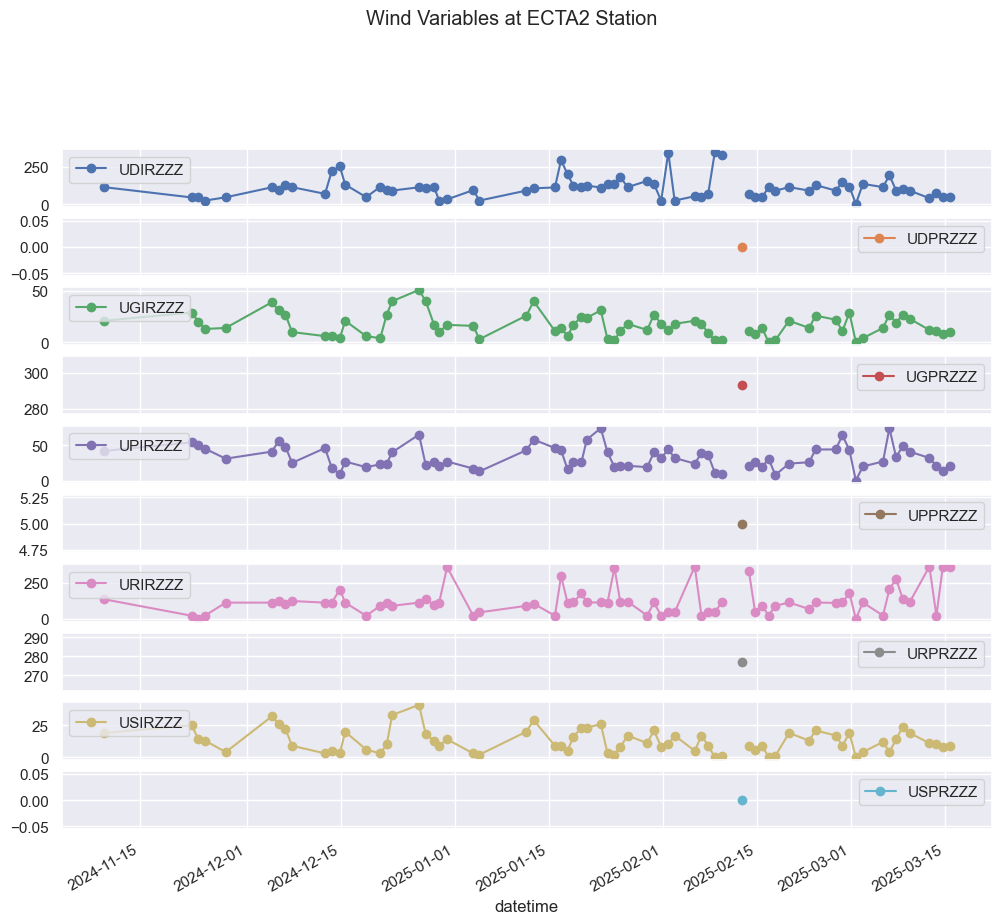

In [152]:
# plot each in it's own subplot 
df_met_ECTA2_wind.plot(subplots=True, figsize=(12, 10), marker='o', linestyle='-')
plt.suptitle('Wind Variables at ECTA2 Station', y=1.02)
plt.show()